In [1]:
import pandas as pd
df = pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [3]:
# Очищаем колонки Price и Milage: убираем знак доллара, запятые, буквы 'mi.' и лишние пробелы
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = df['price'].astype(int)
df['milage'] = df['milage'].str.replace(',', '', regex=False)
df['milage'] = df['milage'].str.replace('mi.', '', regex=False)
df['milage'] = df['milage'].str.strip()
df['milage'] = df['milage'].astype(int)
print("Тип данных price:", df['price'].dtype)
print("Тип данных milage:", df['milage'].dtype)
df[['price', 'milage']].head()

Тип данных price: int64
Тип данных milage: int64


,price,milage
0,10300,51000
1,38005,34742
2,54598,22372
3,15500,88900
4,34999,9835


In [4]:
# Пробуем найти 'Electric' в тексте двигателя или топлива
df['is_electric'] = df['engine'].str.contains('Electric', case=False, na=False) | df['fuel_type'].str.contains('Electric', case=False, na=False)
# Если машина - Tesla, принудительно ставим "Electric" (это перебивает любые ошибки в данных)
df.loc[df['brand'] == 'Tesla', 'fuel_type'] = 'Electric'
# Если машина электрическая (по флагу) и топливо всё еще пустое — ставим 'Electric'
df.loc[df['is_electric'] & df['fuel_type'].isna(), 'fuel_type'] = 'Electric'
df.drop(columns=['is_electric'], inplace=True)
df['fuel_type'] = df['fuel_type'].astype(str).str.strip()
df['fuel_type'] = df['fuel_type'].replace(r'^[-\s—]*$', 'UNKNOWN', regex=True)
df['fuel_type'] = df['fuel_type'].replace(['not supported', 'None', 'nan', ''], 'UNKNOWN')
print(df[df['brand'] == 'Tesla']['fuel_type'].value_counts())

fuel_type
Electric    87
Name: count, dtype: int64


In [5]:
# Заполняем пропуски в авариях и тайтле логичными текстовыми маркерами
df['accident'] = df['accident'].fillna('None reported')
df['clean_title'] = df['clean_title'].fillna('No')
# Находим моду (самое частое значение) для типа топлива
fuel_mode = df['fuel_type'].mode()[0]
df['fuel_type'] = df['fuel_type'].fillna(fuel_mode)
# Проверяем, что пропусков больше не осталось
print("Количество пропущенных значений в датасете:")
print(df.isnull().sum())

Количество пропущенных значений в датасете:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64


In [6]:
# Рассчитываем базовые статистики для Цены (price)
print("СТАТИСТИКА ПО ЦЕНЕ (Price, $)")
print(f"Средняя цена: {df['price'].mean():.2f}")
print(f"Медианная цена (50%): {df['price'].median():.2f}")
print(f"Дисперсия цен: {df['price'].var():.2f}")
print(f"Самая частая цена (Мода): {df['price'].mode()[0]}")
print("")
# Рассчитываем базовые статистики для Пробега (milage)
print("СТАТИСТИКА ПО ПРОБЕГУ (Milage, мили)")
print(f"Средний пробег: {df['milage'].mean():.2f}")
print(f"Медианный пробег (50%): {df['milage'].median():.2f}")
print(f"Дисперсия пробега: {df['milage'].var():.2f}")
print(f"Самый частый пробег (Мода): {df['milage'].mode()[0]}")

СТАТИСТИКА ПО ЦЕНЕ (Price, $)
Средняя цена: 44553.19
Медианная цена (50%): 31000.00
Дисперсия цен: 6195364149.34
Самая частая цена (Мода): 15000

СТАТИСТИКА ПО ПРОБЕГУ (Milage, мили)
Средний пробег: 64717.55
Медианный пробег (50%): 52775.00
Дисперсия пробега: 2734934315.02
Самый частый пробег (Мода): 110000


Размер датасета после удаления выбросов: (3950, 12)


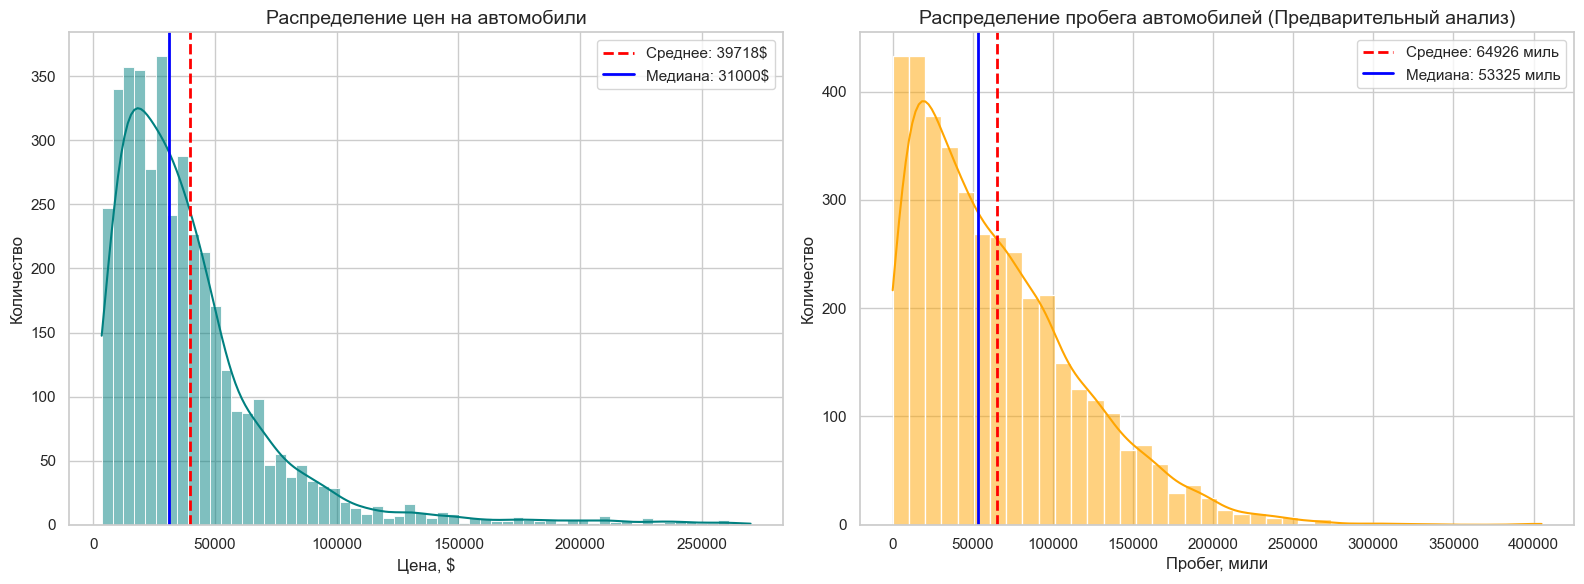

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Очистка от аномальных нулевых и высоких цен
upper_limit_price = df['price'].quantile(0.99)
lower_limit_price = df['price'].quantile(0.005)
df = df[df['price'] <= upper_limit_price]
# Также можно убрать выбросы по пробегу (например, свыше 250k миль)
upper_limit_milage = df['milage'].quantile(0.995)
df = df[(df['price'] >= lower_limit_price) & (df['price'] <= upper_limit_price)]
print(f"Размер датасета после удаления выбросов: {df.shape}")

sns.histplot(df['price'], kde=True, color='teal', ax=axes[0], bins=60)
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df["price"].mean():.0f}$')
axes[0].axvline(df['price'].median(), color='blue', linestyle='-', linewidth=2, label=f'Медиана: {df["price"].median():.0f}$')
axes[0].set_title('Распределение цен на автомобили', fontsize=14)
axes[0].set_xlabel('Цена, $')
axes[0].set_ylabel('Количество')
axes[0].legend()
# Оцениваем распределение пробега в рамках предварительного анализа (ось axes[1])
sns.histplot(df['milage'], kde=True, color='orange', ax=axes[1], bins=40)
axes[1].axvline(df['milage'].mean(), color='red', linestyle='--', linewidth=2, label=f"Среднее: {df['milage'].mean():.0f} миль")
axes[1].axvline(df['milage'].median(), color='blue', linestyle='-', linewidth=2, label=f"Медиана: {df['milage'].median():.0f} миль")
axes[1].set_title('Распределение пробега автомобилей (Предварительный анализ)', fontsize=14)
axes[1].set_xlabel('Пробег, мили')
axes[1].set_ylabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.show()

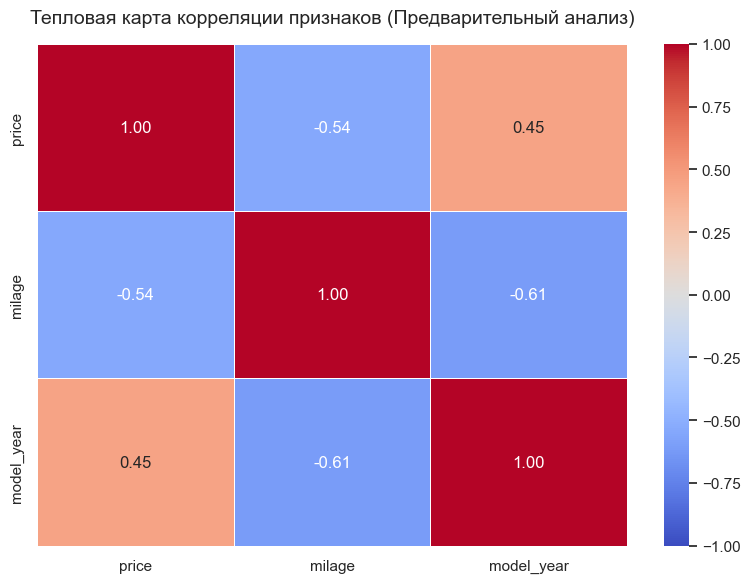

In [8]:
# Выбираем ключевые числовые признаки для предварительного анализа
numerical_cols = ['price', 'milage', 'model_year']
# Рассчитываем матрицу корреляции Пирсона
correlation_matrix = df[numerical_cols].corr()
# Визуализируем матрицу в виде тепловой карты
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Тепловая карта корреляции признаков (Предварительный анализ)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [9]:
# Ищем число, после которого идет буква L (например, 3.7L, 2.0L, 3.5L)
# r'(\d+\.?\d*)\s*L' означает: "найти число, потом пробелы (если есть), потом букву L"
df['engine_size'] = df['engine'].str.extract(r'(\d+\.?\d*)\s*L').astype(float)
# Проверяем, что получилось
print("Первые 10 строк с извлеченным объемом двигателя:")
print(df[['engine', 'engine_size']].head(10))
# Смотрим, сколько пропусков (NaN) у нас осталось (это наши электрокары и гибриды без литража)
nan_count = df['engine_size'].isna().sum()
print(f"\nКоличество машин, у которых не удалось найти литраж (электрокары и т.д.): {nan_count}")

Первые 10 строк с извлеченным объемом двигателя:
                                              engine  engine_size
0  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...          3.7
1                               3.8L V6 24V GDI DOHC          3.8
2                                     3.5 Liter DOHC          3.5
3  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...          3.5
4                         2.0L I4 16V GDI DOHC Turbo          2.0
5                                          2.4 Liter          2.4
6       292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel          2.0
7       282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel          4.4
8      311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel          3.5
9        534.0HP Electric Motor Electric Fuel System          NaN

Количество машин, у которых не удалось найти литраж (электрокары и т.д.): 213


In [10]:
# ОБРАБОТКА ПРОПУСКОВ В ОБЪЕМЕ ДВИГАТЕЛЯ
nan_count = df['engine_size'].isna().sum()
print(f"Количество машин, у которых не указан литраж: {nan_count}")
# Заполняем пропуски МЕДИАНОЙ. 
median_engine = df['engine_size'].median()
df['engine_size'] = df['engine_size'].fillna(median_engine)
print(f"Пропусков после заполнения: {df['engine_size'].isna().sum()}")
print(f"Медиана объема двигателя в выборке: {median_engine} L")

Количество машин, у которых не указан литраж: 213
Пропусков после заполнения: 0
Медиана объема двигателя в выборке: 3.5 L


In [11]:
# Сохраняем чистый датасет для BI-дашборда
# (index=False убирает ненужный столбец с номерами строк)
df.to_csv('car_data_for_BI.csv', index=False)
print("Файл 'car_data_for_BI.csv' успешно сохранен!")

Файл 'car_data_for_BI.csv' успешно сохранен!


In [12]:
import sqlite3

# Создаем соединение с базой данных (файл появится в папке с проектом)
conn = sqlite3.connect('cars_database.db')
cursor = conn.cursor()

# Загружаем данные из датафрейма pandas в таблицу SQL под названием 'cars'
# Если таблица уже существовала, она перезапишется (replace=True)
df.to_sql('cars', conn, if_exists='replace', index=False)

# Проверяем, что данные загрузились
cursor.execute("SELECT COUNT(*) FROM cars")
count = cursor.fetchone()[0]
print(f"База данных создана! Таблица 'cars' содержит {count} записей.")

query_0 = """
select * from cars
limit 5
"""
print(pd.read_sql_query(query_0, conn))

База данных создана! Таблица 'cars' содержит 3950 записей.
      brand                            model  model_year  milage  \
0      Ford  Utility Police Interceptor Base        2013   51000   
1   Hyundai                     Palisade SEL        2021   34742   
2     Lexus                    RX 350 RX 350        2022   22372   
3  INFINITI                 Q50 Hybrid Sport        2015   88900   
4      Audi        Q3 45 S line Premium Plus        2021    9835   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Bl

In [13]:
conn = sqlite3.connect('cars_database.db')
print("ЗАПРОС №1: ТОП-5 самых дорогих брендов (средняя цена)")

query_1 = """
select brand, ROUND(AVG(price), 0) as avg_price
from cars
group by brand
order by avg_price DESC
limit 5
"""
print(pd.read_sql_query(query_1, conn))

ЗАПРОС №1: ТОП-5 самых дорогих брендов (средняя цена)
         brand  avg_price
0  Lamborghini   203852.0
1      Ferrari   193211.0
2      McLaren   168950.0
3  Rolls-Royce   133300.0
4      Bentley   120879.0


In [14]:
print("ЗАПРОС №2: Средняя цена и пробег в зависимости от типа топлива")
query_2 = """
select ROUND(AVG(price), 0) as avg_price, ROUND(AVG(milage), 0) as avg_milage, fuel_type, count(*) as car_count
from cars
group by fuel_type
order by avg_price DESC
limit 5
"""
print(pd.read_sql_query(query_2, conn))

ЗАПРОС №2: Средняя цена и пробег в зависимости от типа топлива
   avg_price  avg_milage       fuel_type  car_count
0    54549.0     25642.0        Electric        168
1    51426.0     42485.0          Hybrid        194
2    48695.0     92862.0          Diesel        116
3    45946.0     32987.0  Plug-In Hybrid         34
4    38812.0     65534.0        Gasoline       3253


In [15]:
print("ЗАПРОС №3: Бренды с самым высоким средним пробегом")
query_3 = """
select brand, round(avg(milage), 0) as avg_milage
from cars
group by brand
order by avg_milage DESC
limit 5
"""
print(pd.read_sql_query(query_3, conn))

ЗАПРОС №3: Бренды с самым высоким средним пробегом
        brand  avg_milage
0      Hummer    132629.0
1       Scion    128509.0
2      Suzuki     99982.0
3  Mitsubishi     97140.0
4        Saab     91600.0


In [16]:
print("ЗАПРОС №4: Сравнение цен на авто с пробегом до 50к миль и свыше 100к миль")
query_4 = """
SELECT 
    CASE 
        WHEN milage < 50000 THEN 'Мало пробега (до 50к)'
        WHEN milage > 100000 THEN 'Много пробега (свыше 100к)'
        ELSE 'Средний пробег'
    END as mileage_category,
    ROUND(AVG(price), 0) as avg_price,
    COUNT(*) as car_count
FROM cars
GROUP BY mileage_category
ORDER BY avg_price DESC;
"""
print(pd.read_sql_query(query_4, conn))

ЗАПРОС №4: Сравнение цен на авто с пробегом до 50к миль и свыше 100к миль
             mileage_category  avg_price  car_count
0       Мало пробега (до 50к)    58625.0       1880
1              Средний пробег    28009.0       1202
2  Много пробега (свыше 100к)    14980.0        868


In [17]:
print("ЗАПРОС №5: Самые свежие и самые старые автомобили в базе")
query_5 = """
SELECT * FROM (
    SELECT brand, model, model_year, 'Самые свежие' as category
    FROM cars
    ORDER BY model_year DESC
    LIMIT 3
)

UNION ALL

SELECT * FROM (
    SELECT brand, model, model_year, 'Самые старые' as category
    FROM cars
    ORDER BY model_year ASC
    LIMIT 3
);
"""
print(pd.read_sql_query(query_5, conn))

ЗАПРОС №5: Самые свежие и самые старые автомобили в базе
    brand              model  model_year      category
0     BMW              M3 CS        2024  Самые свежие
1   Mazda      CX-90 Premium        2024  Самые свежие
2     BMW              M3 CS        2024  Самые свежие
3    Ford             Bronco        1974  Самые старые
4   Mazda    MX-5 Miata Base        1992  Самые старые
5  Toyota  Land Cruiser Base        1993  Самые старые


In [18]:
conn.close()

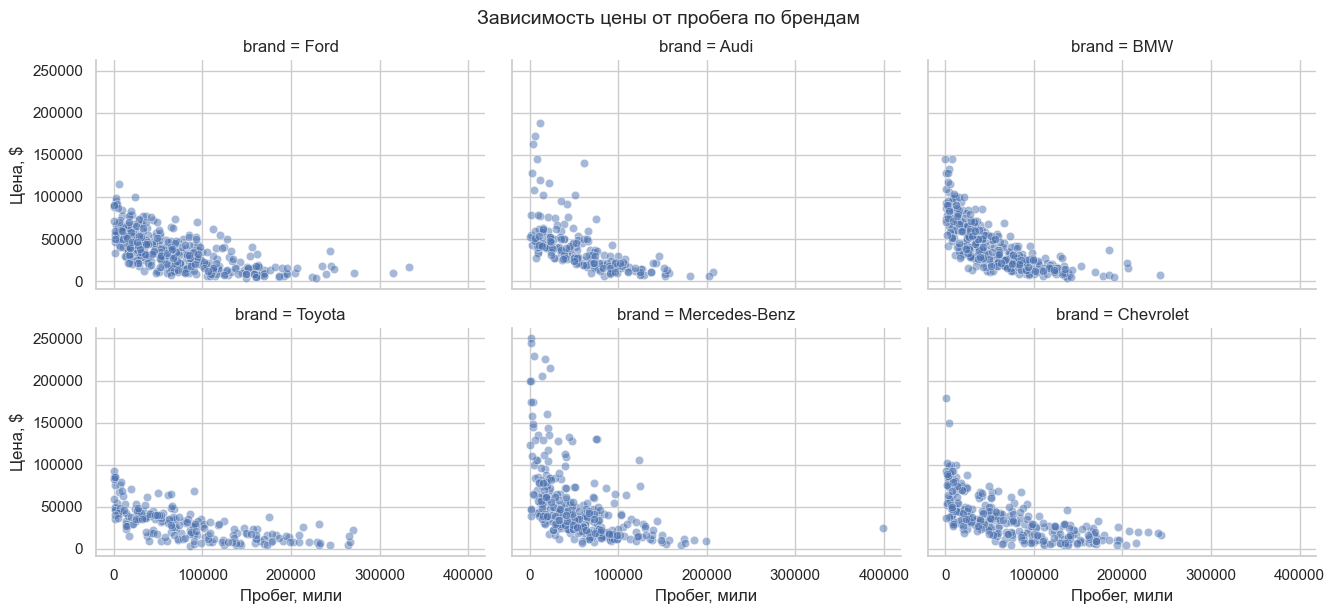

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Выбираем топ-6 брендов по количеству машин
top_brands = df['brand'].value_counts().nlargest(6).index

# Фильтруем датафрейм только под эти бренды
df_top = df[df['brand'].isin(top_brands)]

# Рисуем "сетку" (FacetGrid) — по 6 маленьких графиков в одном окне
g = sns.FacetGrid(df_top, col='brand', col_wrap=3, height=3, aspect=1.5)
g.map(sns.scatterplot, 'milage', 'price', alpha=0.5)
g.set_axis_labels('Пробег, мили', 'Цена, $')
g.fig.suptitle('Зависимость цены от пробега по брендам', fontsize=14, y=1.02)
plt.show()

C:\Users\Alex_K\AppData\Local\Temp\ipykernel_8472\421834119.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend().remove()
C:\Users\Alex_K\AppData\Local\Temp\ipykernel_8472\421834119.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend().remove()


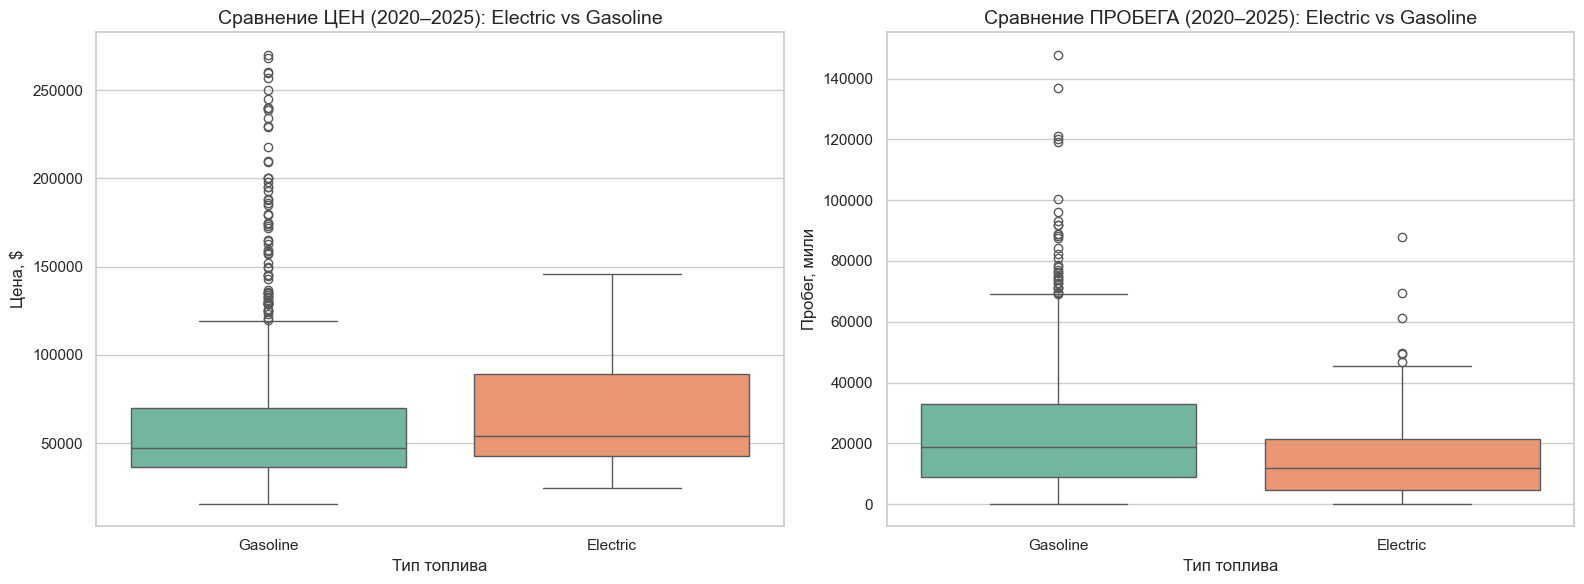

In [20]:
# Гипотеза №2: «Электрокары теряют в цене медленнее, чем бензиновые»
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Подготавливаем данные (свежие авто 2020+, только Electric и Gasoline)
df_recent = df[df['model_year'] >= 2020]
df_compare = df_recent[df_recent['fuel_type'].isin(['Electric', 'Gasoline'])]

# 2. Создаем окно с двумя графиками рядом (1 строка, 2 колонки)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- График слева (Цены) ---
sns.boxplot(x='fuel_type', y='price', data=df_compare, palette='Set2', ax=axes[0], hue='fuel_type')
axes[0].set_title('Сравнение ЦЕН (2020–2025): Electric vs Gasoline', fontsize=14)
axes[0].set_xlabel('Тип топлива')
axes[0].set_ylabel('Цена, $')
axes[0].legend().remove()

# --- График справа (Пробег) ---
sns.boxplot(x='fuel_type', y='milage', data=df_compare, palette='Set2', ax=axes[1], hue='fuel_type')
axes[1].set_title('Сравнение ПРОБЕГА (2020–2025): Electric vs Gasoline', fontsize=14)
axes[1].set_xlabel('Тип топлива')
axes[1].set_ylabel('Пробег, мили')
axes[1].legend().remove()

# 3. Показываем итоговый скриншот
plt.tight_layout()
plt.show()

C:\Users\Alex_K\AppData\Local\Temp\ipykernel_8472\3254266072.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='accident', y='price', data=df_all, palette='Reds', ax=axes[0])
C:\Users\Alex_K\AppData\Local\Temp\ipykernel_8472\3254266072.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='accident', y='price', data=df_filtered, palette='Reds', ax=axes[1])


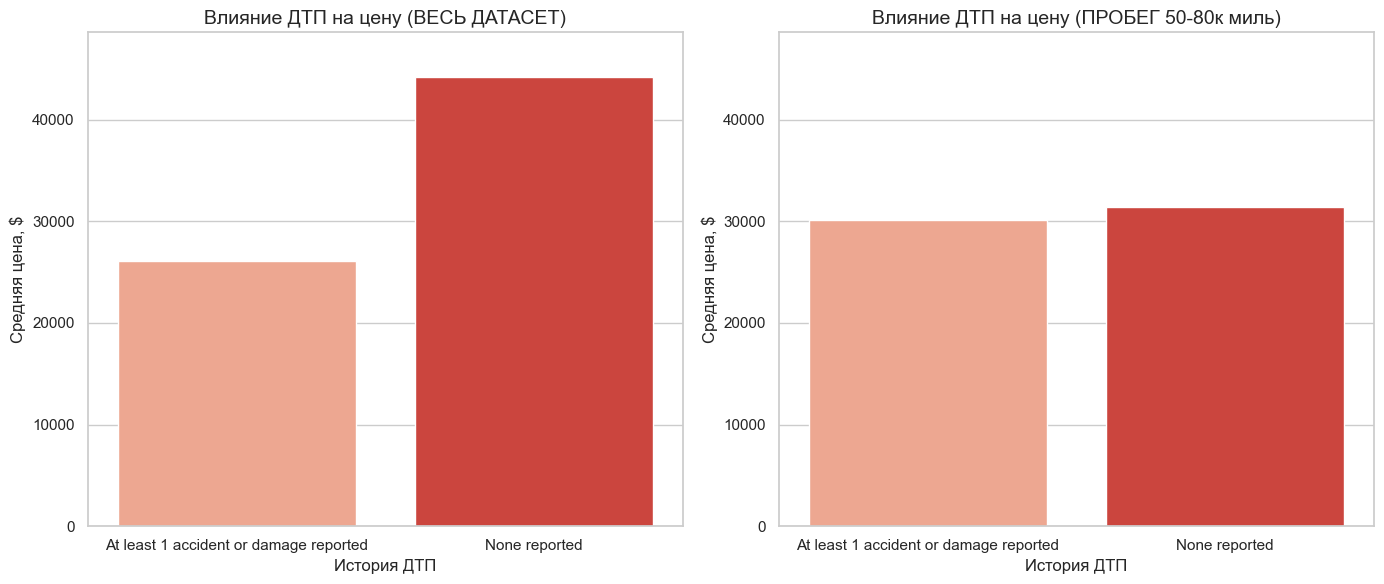

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем общую фигуру (1 строка, 2 колонки)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================
# ГРАФИК 1: БЕЗ ФИЛЬТРА (весь датасет)
# ==========================
# Группируем по авариям и считаем среднюю цену по всему датасету
df_all = df.groupby('accident')['price'].mean().reset_index()

sns.barplot(x='accident', y='price', data=df_all, palette='Reds', ax=axes[0])
axes[0].set_title('Влияние ДТП на цену (ВЕСЬ ДАТАСЕТ)', fontsize=14)
axes[0].set_xlabel('История ДТП')
axes[0].set_ylabel('Средняя цена, $')

# ==========================
# ГРАФИК 2: С ФИЛЬТРОМ ПО ПРОБЕГУ (50k - 80k миль)
# ==========================
# Фильтруем датасет
df_mid_mileage = df[(df['milage'] >= 50000) & (df['milage'] <= 80000)]
# Группируем по авариям
df_filtered = df_mid_mileage.groupby('accident')['price'].mean().reset_index()

sns.barplot(x='accident', y='price', data=df_filtered, palette='Reds', ax=axes[1])
axes[1].set_title('Влияние ДТП на цену (ПРОБЕГ 50-80к миль)', fontsize=14)
axes[1].set_xlabel('История ДТП')
axes[1].set_ylabel('Средняя цена, $')

# Выравниваем оси Y, чтобы сравнение было честным
y_max = max(df_all['price'].max(), df_filtered['price'].max())
axes[0].set_ylim(0, y_max * 1.1)
axes[1].set_ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()

C:\Users\Alex_K\AppData\Local\Temp\ipykernel_8472\2283872883.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='accident', y='price', data=df_accident_impact, palette='Reds')


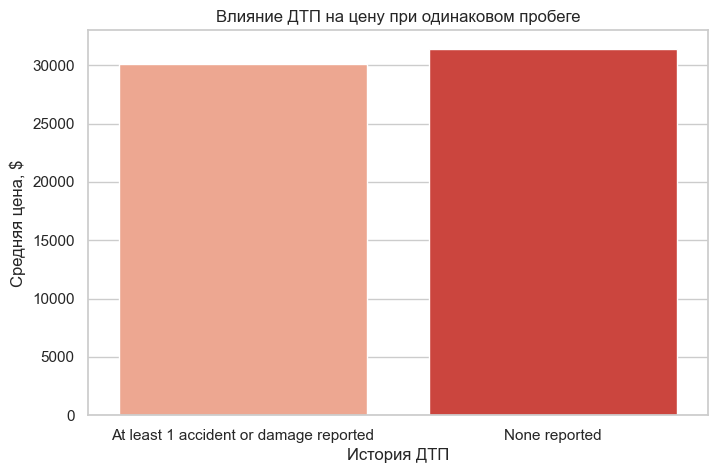

In [22]:
# Гипотеза №4: «Цена после ДТП падает сильнее обычного износа»
# Отбираем машины со средним пробегом (50k - 80k миль)
df_mid_mileage = df[(df['milage'] >= 50000) & (df['milage'] <= 80000)]

# Группируем по наличию аварии и считаем среднюю цену
df_accident_impact = df_mid_mileage.groupby('accident')['price'].mean().reset_index()

# Рисуем простую столбчатую диаграмму
plt.figure(figsize=(8, 5))
sns.barplot(x='accident', y='price', data=df_accident_impact, palette='Reds')
plt.title('Влияние ДТП на цену при одинаковом пробеге')
plt.xlabel('История ДТП')
plt.ylabel('Средняя цена, $')
plt.show()

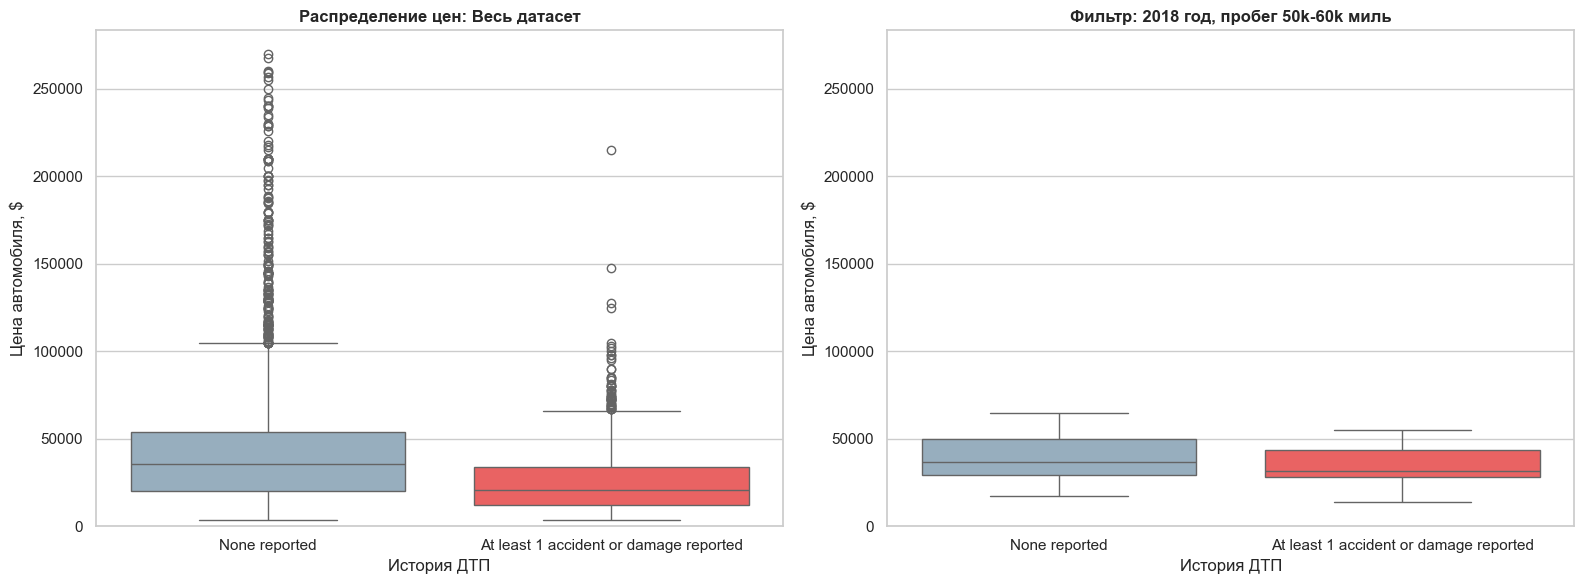

=== Анализ группы: 2018 год, пробег 50000-60000 миль ===
P-value: 0.28367
⚠️ РЕЗУЛЬТАТ: Разница не значима.


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# НАСТРОЙКА ФИЛЬТРОВ
target_year = 2018  
min_mileage = 50000
max_mileage = 60000
# Строгий порядок категорий для обоих графиков
fixed_order = ['None reported', 'At least 1 accident or damage reported']
# Палитра: чистые машины — серо-голубые (нейтральные), с ДТП — красные (внимание)
custom_colors = {'None reported': '#90afc5', 'At least 1 accident or damage reported': '#ff4d4d'}
df_filtered = df[
    (df['model_year'] == target_year) & 
    (df['milage'] >= min_mileage) & 
    (df['milage'] <= max_mileage)
]
# ВИЗУАЛИЗАЦИЯ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# График 1: Весь датасет
sns.boxplot(x='accident', y='price', hue='accident', data=df, 
            order=fixed_order, hue_order=fixed_order, palette=custom_colors, ax=axes[0], legend=False)
axes[0].set_title('Распределение цен: Весь датасет', fontsize=12, fontweight='bold')
axes[0].set_xlabel('История ДТП')
axes[0].set_ylabel('Цена автомобиля, $')
# График 2: Отфильтрованные данные
if not df_filtered.empty:
    sns.boxplot(x='accident', y='price', hue='accident', data=df_filtered, 
                order=fixed_order, hue_order=fixed_order, palette=custom_colors, ax=axes[1], legend=False)
    axes[1].set_title(f'Фильтр: {target_year} год, пробег {min_mileage//1000}k-{max_mileage//1000}k миль', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('История ДТП')
    axes[1].set_ylabel('Цена автомобиля, $')
else:
    axes[1].text(0.5, 0.5, 'Нет данных для указанных фильтров', ha='center', va='center', fontsize=12)
# Выравнивание осей Y
y_max = df['price'].max()
axes[0].set_ylim(0, y_max * 1.05)
axes[1].set_ylim(0, y_max * 1.05)
plt.tight_layout()
plt.show()
# СТАТИСТИЧЕСКИЙ ТЕСТ (T-Test)
group_no_accident = df_filtered[df_filtered['accident'] == 'None reported']['price']
group_with_accident = df_filtered[df_filtered['accident'] != 'None reported']['price']
print(f"=== Анализ группы: {target_year} год, пробег {min_mileage}-{max_mileage} миль ===")
if len(group_no_accident) > 5 and len(group_with_accident) > 5:
    t_stat, p_val = stats.ttest_ind(group_no_accident, group_with_accident, equal_var=False)
    print(f"P-value: {p_val:.5f}")
    if p_val < 0.05:
        print("💡 РЕЗУЛЬТАТ: Разница СТАТИСТИЧЕСКИ ЗНАЧИМА. ДТП снижает цену!")
    else:
        print("⚠️ РЕЗУЛЬТАТ: Разница не значима.")
else:
    print("❌ ОШИБКА: Недостаточно данных для теста.")

In [24]:
# Гипотеза №3: Влияние типа коробки передач на цену
# Список всех возможных вариантов написания "ручной коробки"
manual_variants = ['Manual', 'M/T', 'M.T.', 'MT', 'mt', 'm.t.', 'm/t', 'Mt', '5-Speed Manual', '6-Speed Manual', 
                   '6 Speed Mt', '7-Speed M/T', '5-Speed M/T', '6-Speed M/T']
is_manual = df['transmission'].str.contains('manual', case=False, na=False)
df.loc[is_manual, 'transmission'] = 'Manual'
# Заменяем их все на одно значение "Manual"
df['transmission'] = df['transmission'].replace(manual_variants, 'Manual')
# Смотрим, сколько теперь стало "Manual"
print(f"Количество машин с механической коробкой после унификации: {df[df['transmission'] == 'Manual'].shape[0]}")

Количество машин с механической коробкой после унификации: 366


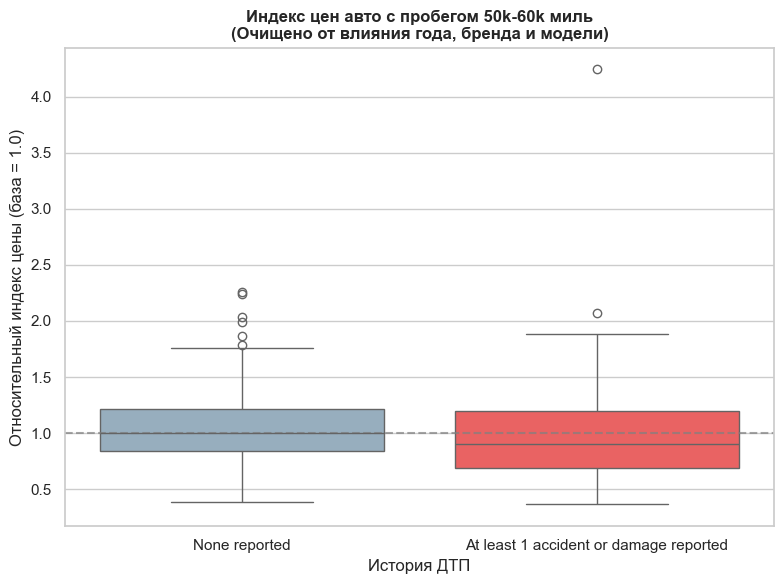

=== Глобальный анализ очищенных данных (пробег 50k-60k) ===
P-value: 0.4650941767
Медианный индекс без ДТП: 1.00
Медианный индекс с ДТП: 0.90


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Считаем среднюю цену для каждой комбинации Модель + Год выпуска
df_grouped = df.groupby(['brand', 'model_year'])['price'].transform('mean')
# 2. Создаем нормализованный индекс цены (отношение цены машины к средней цене такой же целой/битой модели этого года)
# Значение 1.0 означает среднюю цену рынка для этой модели. Всё что ниже 1.0 — удешевление.
df['price_index'] = df['price'] / df_grouped

# 3. Фильтруем по узкому пробегу, но уже по ВСЕМ годам и моделям сразу!
df_macro = df[(df['milage'] >= 50000) & (df['milage'] <= 60000)].dropna(subset=['price_index'])

# Строгий порядок категорий и цвета
fixed_order = ['None reported', 'At least 1 accident or damage reported']
custom_colors = {'None reported': '#90afc5', 'At least 1 accident or damage reported': '#ff4d4d'}

# Визуализация индекса цен
plt.figure(figsize=(8, 6))
sns.boxplot(x='accident', y='price_index', hue='accident', data=df_macro, 
            order=fixed_order, hue_order=fixed_order, palette=custom_colors, legend=False)
plt.title('Индекс цен авто с пробегом 50k-60k миль\n(Очищено от влияния года, бренда и модели)', fontsize=12, fontweight='bold')
plt.xlabel('История ДТП')
plt.ylabel('Относительный индекс цены (база = 1.0)')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Проводим глобальный T-test очищенных данных
g_no = df_macro[df_macro['accident'] == 'None reported']['price_index']
g_yes = df_macro[df_macro['accident'] != 'None reported']['price_index']

print(f"=== Глобальный анализ очищенных данных (пробег 50k-60k) ===")
if len(g_no) > 5 and len(g_yes) > 5:
    t_stat, p_val = stats.ttest_ind(g_no, g_yes, equal_var=False)
    print(f"P-value: {p_val:.10f}")
    print(f"Медианный индекс без ДТП: {g_no.median():.2f}")
    print(f"Медианный индекс с ДТП: {g_yes.median():.2f}")
    if p_val < 0.05:
        print("💡 ИТОГ: Разница очищенных цен абсолютно значима! ДТП гарантированно снижает стоимость автомобиля.")


In [26]:
print("Количество машин по типам коробок передач:")

Количество машин по типам коробок передач:


In [27]:
print(df['transmission'].value_counts())

transmission
A/T                                                   1023
8-Speed A/T                                            405
Transmission w/Dual Shift Mode                         395
Manual                                                 366
6-Speed A/T                                            362
Automatic                                              233
7-Speed A/T                                            206
8-Speed Automatic                                      169
10-Speed A/T                                           119
5-Speed A/T                                             85
9-Speed A/T                                             74
6-Speed Automatic                                       73
4-Speed A/T                                             70
1-Speed A/T                                             64
CVT Transmission                                        61
10-Speed Automatic                                      55
9-Speed Automatic                          

In [28]:
df['transmission_group'] = df['transmission']

# 2. Правило для МЕХАНИКИ (Manual)
df.loc[df['transmission_group'] == 'Manual', 'transmission_group'] = 'Manual'

# 3. Правило для АВТОМАТА (AT) 
# Ищем Automatic, A/T, Speed, CVT, Shift, Clutch, AT, Auto, а также Variable (вариатор)
at_mask = df['transmission_group'].str.contains('Automatic|A/T|Speed|CVT|Shift|Clutch|AT|Auto|Variable', case=False, na=False)
df.loc[at_mask, 'transmission_group'] = 'AT (Automatic)'

# 4. Всё, что не попало в Механику или Автомат — НЕИЗВЕСТНЫЕ (Unknown)
df['transmission_group'] = df['transmission_group'].replace(['-', 'F', '2-Speed A/T', '6 Speed At/Mt'], 'Unknown')

# 5. Выводим итоговый подсчёт
print("=== Итоговое распределение трансмиссий (3 группы) ===")
print(df['transmission_group'].value_counts())
df['transmission_group'] = df['transmission_group'].replace(
    ['Transmission Overdrive Switch', '-', '2', 'SCHEDULED FOR OR IN PRODUCTION'], 
    'Unknown'
)

# Проверяем финальное распределение
print("=== ФИНАЛЬНОЕ распределение трансмиссий ===")
print(df['transmission_group'].value_counts())

=== Итоговое распределение трансмиссий (3 группы) ===
transmission_group
AT (Automatic)                    3568
Manual                             366
Transmission Overdrive Switch        7
–                                    3
2                                    3
Unknown                              2
SCHEDULED FOR OR IN PRODUCTION       1
Name: count, dtype: int64
=== ФИНАЛЬНОЕ распределение трансмиссий ===
transmission_group
AT (Automatic)    3568
Manual             366
Unknown             13
–                    3
Name: count, dtype: int64


C:\Users\Alex_K\AppData\Local\Temp\ipykernel_8472\514654874.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


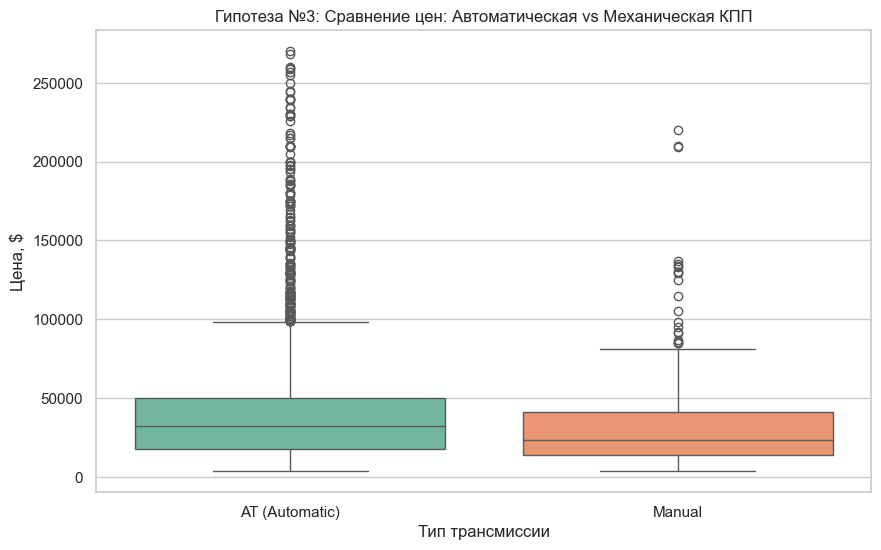

In [29]:
# ФИЛЬТРУЕМ только Automatic и Manual, игнорируем Unknown (их всего 13)
df_clean_trans = df[df['transmission_group'].isin(['AT (Automatic)', 'Manual'])]

# Строим Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='transmission_group', y='price', data=df_clean_trans, palette='Set2', hue='transmission_group')
plt.title('Гипотеза №3: Сравнение цен: Автоматическая vs Механическая КПП')
plt.xlabel('Тип трансмиссии')
plt.ylabel('Цена, $')
plt.legend().remove()
plt.show()

In [30]:
# Сохраняем обновленный датафрейм с новой колонкой transmission_group
df.to_csv('car_data_for_BI_final.csv', index=False)
print("✅ Датасет с новой группировкой трансмиссий сохранен в 'car_data_for_BI_final.csv'.")

✅ Датасет с новой группировкой трансмиссий сохранен в 'car_data_for_BI_final.csv'.


In [31]:
from scipy import stats
import pandas as pd
import numpy as np
print("ГИПОТЕЗА 1: Корреляция 'Пробег vs Цена' в разрезе брендов")
# Берем топ-5 брендов по количеству машин (те, что были на графике FacetGrid)
top_brands = df['brand'].value_counts().nlargest(6).index

ГИПОТЕЗА 1: Корреляция 'Пробег vs Цена' в разрезе брендов


In [32]:
print("Анализ корреляции для топ-6 брендов:\n")

for brand in top_brands:
    # Фильтруем данные только по текущему бренду
    df_brand = df[df['brand'] == brand]
    
    # Считаем корреляцию Пирсона
    corr, p_val = stats.pearsonr(df_brand['milage'], df_brand['price'])
    
    # Выводим результат
    status = "✅ Значимо" if p_val < 0.05 else "❌ Не значимо"
    print(f"Бренд: {brand:<15} | r = {corr:<6.3f} | p-value = {p_val:<.4e} | {status}")

print("\n" + "=" * 60)
print("ВЫВОД ПО ГИПОТЕЗЕ 1:")
print("""
Гипотеза заключается в том, что премиальные бренды меньше теряют в цене при пробеге.
Смотрим на коэффициенты корреляции (r). Чем ближе r к -1, тем сильнее цена падает с пробегом.
Если у одного бренда r = -0.90, а у другого r = -0.30, значит, бренд действительно смягчает влияние пробега.

Окончательное заключение делается на основе сравнения этих коэффициентов и их p-значений.
""")

Анализ корреляции для топ-6 брендов:

Бренд: Ford            | r = -0.632 | p-value = 3.9087e-44 | ✅ Значимо
Бренд: BMW             | r = -0.712 | p-value = 3.4004e-59 | ✅ Значимо
Бренд: Mercedes-Benz   | r = -0.486 | p-value = 5.7002e-20 | ✅ Значимо
Бренд: Chevrolet       | r = -0.650 | p-value = 2.0729e-36 | ✅ Значимо
Бренд: Audi            | r = -0.588 | p-value = 5.7399e-20 | ✅ Значимо
Бренд: Toyota          | r = -0.667 | p-value = 7.4514e-27 | ✅ Значимо

ВЫВОД ПО ГИПОТЕЗЕ 1:

Гипотеза заключается в том, что премиальные бренды меньше теряют в цене при пробеге.
Смотрим на коэффициенты корреляции (r). Чем ближе r к -1, тем сильнее цена падает с пробегом.
Если у одного бренда r = -0.90, а у другого r = -0.30, значит, бренд действительно смягчает влияние пробега.

Окончательное заключение делается на основе сравнения этих коэффициентов и их p-значений.



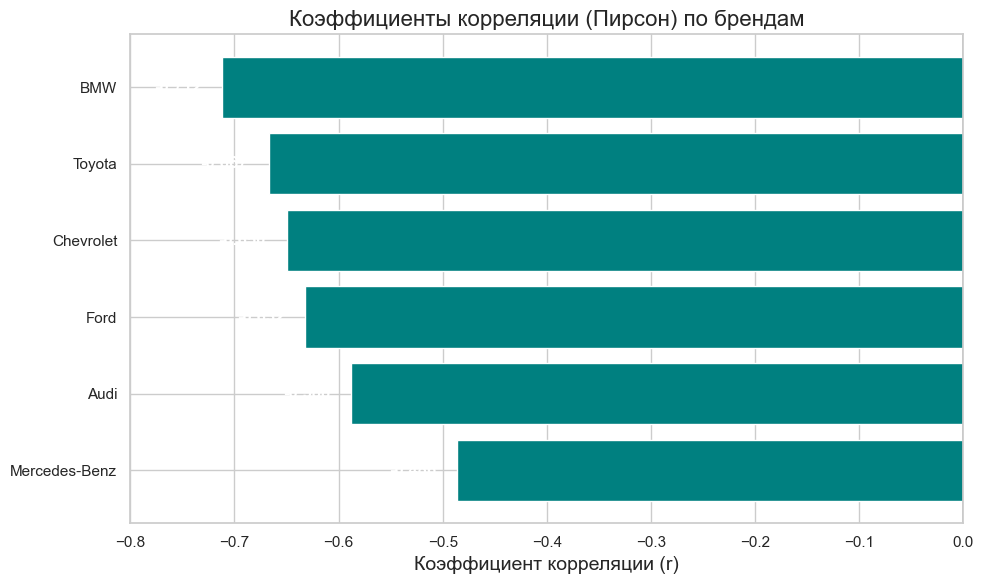

In [33]:
import matplotlib.pyplot as plt

# Данные, которые мы получили
brands = ['BMW', 'Toyota', 'Chevrolet', 'Ford', 'Audi', 'Mercedes-Benz']
correlations = [-0.712, -0.667, -0.650, -0.632, -0.588, -0.486]

# Сортируем данные, чтобы столбики шли по убыванию (от самых сильных к самым слабым)
sorted_data = sorted(zip(correlations, brands), reverse=True)
corr_sorted = [x[0] for x in sorted_data]
brand_sorted = [x[1] for x in sorted_data]

# Строим горизонтальную диаграмму
plt.figure(figsize=(10, 6))
bars = plt.barh(brand_sorted, corr_sorted, color='teal')

# Подписываем значения прямо на столбиках
for bar, val in zip(bars, corr_sorted):
    plt.text(val - 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
             va='center', ha='right', color='white', fontsize=12, fontweight='bold')

# Оформление
plt.axvline(0, color='black', linewidth=1)
plt.title('Коэффициенты корреляции (Пирсон) по брендам', fontsize=16)
plt.xlabel('Коэффициент корреляции (r)', fontsize=14)
plt.xlim(-0.8, 0)
plt.tight_layout()
plt.show()

In [34]:
print("ГИПОТЕЗА 2: T-Test (Electric vs Gasoline) - Сравнение ЦЕН и ПРОБЕГА")
print("=" * 60)
df_recent = df[df['model_year'] >= 2020]

group_electric = df_recent[df_recent['fuel_type'] == 'Electric']
group_gasoline = df_recent[df_recent['fuel_type'] == 'Gasoline']

# 1. Тест для ЦЕНЫ
t_price, p_price = stats.ttest_ind(group_electric['price'], group_gasoline['price'])

# 2. Тест для ПРОБЕГА
t_milage, p_milage = stats.ttest_ind(group_electric['milage'], group_gasoline['milage'])

print(f"--- СРАВНЕНИЕ ЦЕН ---")
print(f"T-статистика (цена): {t_price:.4f}")
print(f"P-значение (цена): {p_price:.4e}")

print(f"\n--- СРАВНЕНИЕ ПРОБЕГА ---")
print(f"T-статистика (пробег): {t_milage:.4f}")
print(f"P-значение (пробег): {p_milage:.4e}")

print("\n" + "=" * 60)
print("ВЫВОД ПО ГИПОТЕЗЕ 2:")
if p_price < 0.05:
    print("✅ Цена: Разница статистически значима.")
else:
    print("❌ Цена: Разница НЕ значима.")

if p_milage < 0.05:
    print("✅ Пробег: Разница статистически значима.")
else:
    print("❌ Пробег: Разница НЕ значима.")

ГИПОТЕЗА 2: T-Test (Electric vs Gasoline) - Сравнение ЦЕН и ПРОБЕГА
--- СРАВНЕНИЕ ЦЕН ---
T-статистика (цена): 0.5599
P-значение (цена): 5.7563e-01

--- СРАВНЕНИЕ ПРОБЕГА ---
T-статистика (пробег): -4.4324
P-значение (пробег): 1.0302e-05

ВЫВОД ПО ГИПОТЕЗЕ 2:
❌ Цена: Разница НЕ значима.
✅ Пробег: Разница статистически значима.


In [35]:
print("ГИПОТЕЗА 3: T-Test (AT vs Manual) - Сравнение цен")
print("=" * 60)

group_at = df[df['transmission_group'] == 'AT (Automatic)']['price']
group_manual = df[df['transmission_group'] == 'Manual']['price']

t_stat, p_val = stats.ttest_ind(group_at, group_manual)

print(f"T-статистика: {t_stat:.4f}")
print(f"P-значение: {p_val:.4e}")

if p_val < 0.05:
    print("✅ ВЫВОД: Разница в ценах статистически значима. Гипотеза о том, что автоматы дороже, ПОДТВЕРЖДЕНА.")
else:
    print("❌ ВЫВОД: Разница статистически не значима. Гипотеза НЕ ПОДТВЕРЖДЕНА.")

print("\n")

ГИПОТЕЗА 3: T-Test (AT vs Manual) - Сравнение цен
T-статистика: 4.0627
P-значение: 4.9451e-05
✅ ВЫВОД: Разница в ценах статистически значима. Гипотеза о том, что автоматы дороже, ПОДТВЕРЖДЕНА.




In [36]:
# ГИПОТЕЗА 4: ДВА T-TEST (С ФИЛЬТРОМ И БЕЗ ФИЛЬТРА)
# ==========================================
print("=" * 60)
print("ГИПОТЕЗА 4: Влияние ДТП на цену (с фильтром и без)")
print("=" * 60)

# --- ТЕСТ 1: БЕЗ ФИЛЬТРА ПО ПРОБЕГУ ---
group_accident_all = df[df['accident'] != 'None reported']['price']
group_clean_all = df[df['accident'] == 'None reported']['price']

t_all, p_all = stats.ttest_ind(group_accident_all, group_clean_all)

print("--- ТЕСТ 1: БЕЗ ФИЛЬТРА (весь датасет) ---")
print(f"T-статистика: {t_all:.4f}")
print(f"P-значение: {p_all:.4e}")

# --- ТЕСТ 2: С ФИЛЬТРОМ ПО ПРОБЕГУ (50k - 80k миль) ---
df_mid = df[(df['milage'] >= 50000) & (df['milage'] <= 80000)]
group_accident_mid = df_mid[df_mid['accident'] != 'None reported']['price']
group_clean_mid = df_mid[df_mid['accident'] == 'None reported']['price']

t_mid, p_mid = stats.ttest_ind(group_accident_mid, group_clean_mid)

print("\n--- ТЕСТ 2: С ФИЛЬТРОМ ПО ПРОБЕГУ (50k-80k миль) ---")
print(f"T-статистика: {t_mid:.4f}")
print(f"P-значение: {p_mid:.4e}")

print("\n" + "=" * 60)
print("ВЫВОД ПО ГИПОТЕЗЕ 4:")
if p_all < 0.05:
    print("✅ Без фильтра: Разница статистически значима.")
else:
    print("❌ Без фильтра: Разница НЕ значима.")

if p_mid < 0.05:
    print("✅ С фильтром (50-80k): Разница статистически значима.")
else:
    print("❌ С фильтром (50-80k): Разница НЕ значима.")

ГИПОТЕЗА 4: Влияние ДТП на цену (с фильтром и без)
--- ТЕСТ 1: БЕЗ ФИЛЬТРА (весь датасет) ---
T-статистика: -14.4360
P-значение: 4.4944e-46

--- ТЕСТ 2: С ФИЛЬТРОМ ПО ПРОБЕГУ (50k-80k миль) ---
T-статистика: -1.0171
P-значение: 3.0942e-01

ВЫВОД ПО ГИПОТЕЗЕ 4:
✅ Без фильтра: Разница статистически значима.
❌ С фильтром (50-80k): Разница НЕ значима.


In [37]:
# ФУНКЦИЯ: ПЕРЕВОД P-VALUE В ПОНЯТНЫЙ ТЕКСТ
# ==========================================
def interpret_pvalue(p_val, test_name):
    # Перевод в проценты
    percent = p_val * 100
    if p_val < 0.001:
        text = f"Менее 0.1% (p-value = {p_val:.4e})"
        conclusion = "Разница крайне значима и не может быть случайной."
    elif p_val < 0.01:
        text = f"Менее 1% (p-value = {p_val:.4f})"
        conclusion = "Разница очень значима."
    elif p_val < 0.05:
        text = f"Менее 5% (p-value = {p_val:.4f})"
        conclusion = "Разница статистически значима (стандартный порог)."
    else:
        text = f"Более 5% (p-value = {p_val:.4f})"
        conclusion = "Разница НЕ является статистически значимой — может быть случайной."
    
    print(f"--- {test_name} ---")
    print(f"Вероятность случайности: {text}")
    print(f"Вывод: {conclusion}")
    print("")

# ==========================================
# ПРИМЕНЯЕМ К ТВОИМ РЕЗУЛЬТАТАМ
# ==========================================

# Пример для Гипотезы 2 (Цена и Пробег)
# Если у тебя есть переменные p_price и p_milage из прошлого запуска:
if 'p_price' in locals():
    interpret_pvalue(p_price, "Гипотеза 2: Разница в ЦЕНЕ между Electric и Gasoline")
if 'p_milage' in locals():
    interpret_pvalue(p_milage, "Гипотеза 2: Разница в ПРОБЕГЕ между Electric и Gasoline")

# Пример для Гипотезы 4 (ДТП с фильтром и без)
# Если у тебя есть переменные p_all и p_mid:
if 'p_all' in locals():
    interpret_pvalue(p_all, "Гипотеза 4: Влияние ДТП (БЕЗ фильтра по пробегу)")
if 'p_mid' in locals():
    interpret_pvalue(p_mid, "Гипотеза 4: Влияние ДТП (С фильтром 50-80k миль)")

# Пример для Гипотезы 3 (AT vs Manual)
# Если у тебя есть переменная p_val (или p_3):
if 'p_val' in locals():
    interpret_pvalue(p_val, "Гипотеза 3: Автомат vs Механика")

--- Гипотеза 2: Разница в ЦЕНЕ между Electric и Gasoline ---
Вероятность случайности: Более 5% (p-value = 0.5756)
Вывод: Разница НЕ является статистически значимой — может быть случайной.

--- Гипотеза 2: Разница в ПРОБЕГЕ между Electric и Gasoline ---
Вероятность случайности: Менее 0.1% (p-value = 1.0302e-05)
Вывод: Разница крайне значима и не может быть случайной.

--- Гипотеза 4: Влияние ДТП (БЕЗ фильтра по пробегу) ---
Вероятность случайности: Менее 0.1% (p-value = 4.4944e-46)
Вывод: Разница крайне значима и не может быть случайной.

--- Гипотеза 4: Влияние ДТП (С фильтром 50-80k миль) ---
Вероятность случайности: Более 5% (p-value = 0.3094)
Вывод: Разница НЕ является статистически значимой — может быть случайной.

--- Гипотеза 3: Автомат vs Механика ---
Вероятность случайности: Менее 0.1% (p-value = 4.9451e-05)
Вывод: Разница крайне значима и не может быть случайной.



In [38]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Извлекаем число перед 'HP' (Horsepower) из столбца 'engine'
# Регулярное выражение ищет любые цифры (включая точки), после которых идет 'HP'
df['power'] = df['engine'].str.extract(r'([\d\.]+)\s*HP').astype(float)

# Удаляем строки, где мощность не указалась (например, электрокары или пропуски)
df_power = df.dropna(subset=['power']).copy()
print("Медианная мощность в датасете:", df_power['power'].median(), "HP")

Медианная мощность в датасете: 310.0 HP


In [39]:
# Пишем функцию строго по вашей логике из PowerBI (пункты 1-8)
def get_power_segment(hp):
    if hp <= 150:
        return "1. Эконом (до 150 л.с.)"
    elif hp <= 250:
        return "2. Стандарт (151-250 л.с.)"
    elif hp <= 400:
        return "3. Бизнес (251-400 л.с.)"
    elif hp <= 600:
        return "4. Спорт (401-600 л.с.)"
    else:
        return "5. Суперкары (600+ л.с.)"

# Применяем сегментацию к извлеченной мощности
df_power['power_segment'] = df_power['power'].apply(get_power_segment)

# Проверяем, сколько машин попало в каждую группу
print(df_power['power_segment'].value_counts().sort_index())

power_segment
1. Эконом (до 150 л.с.)        108
2. Стандарт (151-250 л.с.)     717
3. Бизнес (251-400 л.с.)      1570
4. Спорт (401-600 л.с.)        701
5. Суперкары (600+ л.с.)        77
Name: count, dtype: int64


In [40]:
df_power['price'] = df_power['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
# Проверяем результат
print(df_power['price'].head())
print("\nНовый тип данных колонки price:", df_power['price'].dtype)


g1 = df_power[df_power['power_segment'] == "1. Эконом (до 150 л.с.)"]['price']
g2 = df_power[df_power['power_segment'] == "2. Стандарт (151-250 л.с.)"]['price']
g3 = df_power[df_power['power_segment'] == "3. Бизнес (251-400 л.с.)"]['price']
g4 = df_power[df_power['power_segment'] == "4. Спорт (401-600 л.с.)"]['price']
g5 = df_power[df_power['power_segment'] == "5. Суперкары (600+ л.с.)"]['price']

# Запускаем однофакторный дисперсионный анализ (ANOVA)
f_stat, p_val_anova = stats.f_oneway(g1, g2, g3, g4, g5)

print(f"=== Результаты ANOVA теста для всех групп ===")
print(f"F-статистика: {f_stat:.4f}")
print(f"P-value: {p_val_anova:.10f}")

0    10300.0
3    15500.0
6    31000.0
7     7300.0
8    41927.0
Name: price, dtype: float64

Новый тип данных колонки price: float64
=== Результаты ANOVA теста для всех групп ===
F-статистика: 456.2675
P-value: 0.0000000000


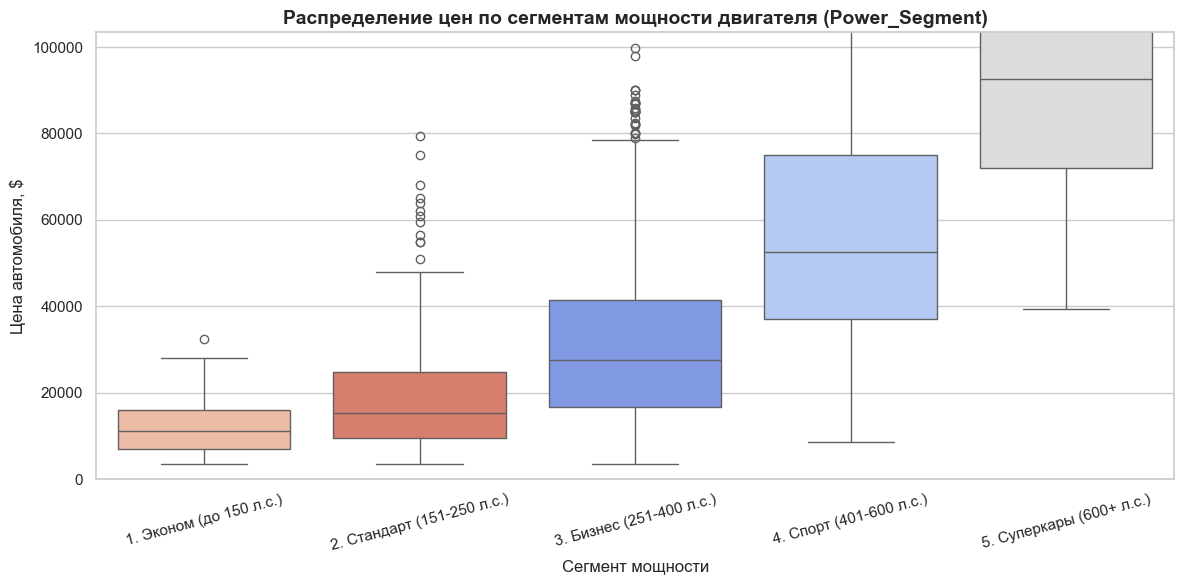

In [41]:
# Задаем правильный порядок отображения ваших групп на графике
custom_order = [
    "1. Эконом (до 150 л.с.)",
    "2. Стандарт (151-250 л.с.)",
    "3. Бизнес (251-400 л.с.)",
    "4. Спорт (401-600 л.с.)",
    "5. Суперкары (600+ л.с.)"
]

plt.figure(figsize=(12, 6))

# Строим график для всех групп с плавным переходом цвета от синего к красному
sns.boxplot(x='power_segment', y='price', hue='power_segment', data=df_power, 
            order=custom_order, palette='coolwarm', legend=False)

plt.title('Распределение цен по сегментам мощности двигателя (Power_Segment)', fontsize=14, fontweight='bold')
plt.xlabel('Сегмент мощности')
plt.ylabel('Цена автомобиля, $')
plt.xticks(rotation=15) # Немного наклоним текст, чтобы группы не налезали друг на друга

# Срезаем выбросы, чтобы масштаб был читаемым
plt.ylim(0, df_power['price'].quantile(0.95) * 1.1)

plt.tight_layout()
plt.show()

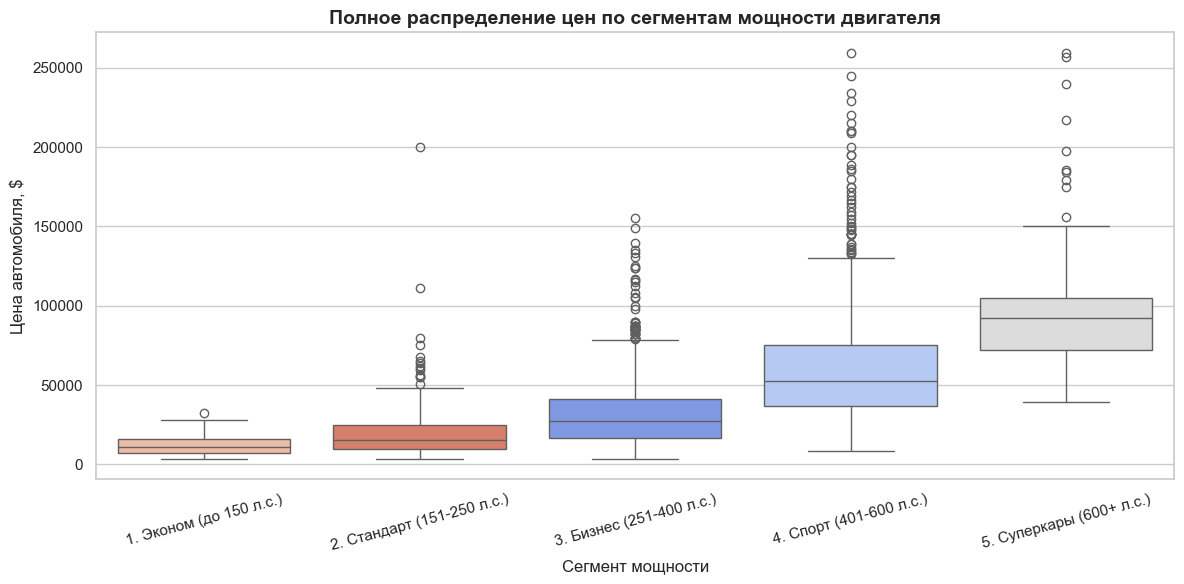

In [42]:
plt.figure(figsize=(12, 6))

# Строим график для всех групп без искусственного ограничения высоты
sns.boxplot(x='power_segment', y='price', hue='power_segment', data=df_power, 
            order=custom_order, palette='coolwarm', legend=False)

plt.title('Полное распределение цен по сегментам мощности двигателя', fontsize=14, fontweight='bold')
plt.xlabel('Сегмент мощности')
plt.ylabel('Цена автомобиля, $')
plt.xticks(rotation=15)

# Автоматический масштаб графика подстроит ось Y под самую дорогую машину
plt.tight_layout()
plt.show()

In [43]:
print(df_power['ext_col'].value_counts().head(20))

ext_col
Black                      812
White                      741
Gray                       459
Silver                     344
Blue                       321
Red                        233
Green                       66
Brown                       43
Gold                        40
Orange                      36
Beige                       36
Yellow                      28
Purple                      11
Silky Silver                 1
Pink                         1
Midnight Black Metallic      1
Name: count, dtype: int64


In [44]:
mass_colors = ['Black', 'White', 'Gray', 'Silver']

# Создаем новый признак группы цвета
df_power['color_group'] = np.where(df_power['ext_col'].isin(mass_colors), 'Базовые (Black/White/Gray/Silver)', 'Экзотика (Редкие/Яркие)')

# Проверяем, сколько машин оказалось в каждой группе
print(df_power['color_group'].value_counts())

color_group
Базовые (Black/White/Gray/Silver)    2356
Экзотика (Редкие/Яркие)               817
Name: count, dtype: int64


In [45]:
# Рассчитываем заново индекс цен на уровне бренда и года (чтобы исключить влияние возраста и марки)
df_power['brand_year_mean'] = df_power.groupby(['brand', 'model_year'])['price'].transform('mean')
df_power['price_index'] = df_power['price'] / df_power['brand_year_mean']

# Выделяем группы для теста (удаляем пустые значения индекса, если они есть)
df_clean_colors = df_power.dropna(subset=['price_index'])
group_base = df_clean_colors[df_clean_colors['color_group'] == 'Базовые (Black/White/Gray/Silver)']['price_index']
group_exotic = df_clean_colors[df_clean_colors['color_group'] == 'Экзотика (Редкие/Яркие)']['price_index']

# Смотрим медианы
print("Медианный индекс для базовых цветов:", round(group_base.median(), 3))
print("Медианный индекс для экзотических цветов:", round(group_exotic.median(), 3))

Медианный индекс для базовых цветов: 0.971
Медианный индекс для экзотических цветов: 1.0


In [46]:
t_stat, p_val = stats.ttest_ind(group_base, group_exotic, equal_var=False)
print(f"=== Результаты T-test по группам цветов ===")
print(f"Т-статистика: {t_stat:.4f}")
print(f"P-value: {p_val:.10f}")

=== Результаты T-test по группам цветов ===
Т-статистика: -1.1573
P-value: 0.2473530887


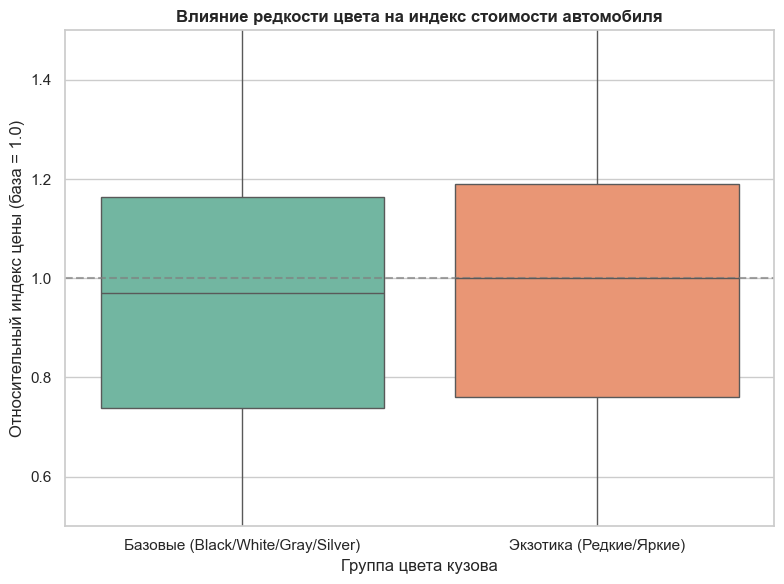

In [47]:
plt.figure(figsize=(8, 6))

# Строим boxplot для сравнения базовых и экзотических цветов
sns.boxplot(x='color_group', y='price_index', hue='color_group', data=df_clean_colors, 
            palette='Set2', legend=False)

plt.title('Влияние редкости цвета на индекс стоимости автомобиля', fontsize=12, fontweight='bold')
plt.xlabel('Группа цвета кузова')
plt.ylabel('Относительный индекс цены (база = 1.0)')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7)

# Ограничим ось Y, чтобы выбросы не сжимали график
plt.ylim(0.5, 1.5)

plt.tight_layout()
plt.show()

In [48]:
print(df_power['int_col'].value_counts().head(15))

int_col
Black     1679
Beige      514
Gray       426
Brown      154
White      116
Red        113
–           91
Blue        26
Orange      20
Silver      15
Gold        10
Green        7
Yellow       2
Name: count, dtype: int64


In [49]:
def check_style_match(row):
    ext = str(row['ext_col']).strip()
    int_col = str(row['int_col']).strip()
    
    # 1. Строгая классика: кузов и салон одного цвета (например, черный на черном)
    if ext == int_col:
        return 'Строгая классика (В цвет)'
    
    # 2. Популярные нейтральные сочетания (Белый/Серый/Серебристый кузов с Черным или Серым салоном)
    elif ext in ['White', 'Gray', 'Silver'] and int_col in ['Black', 'Gray']:
        return 'Популярный нейтрал'
    
    # 3. Цветовой диссонанс / Экзотический контраст (Яркие цвета кузова с яркими салонами)
    elif ext in ['Blue', 'Red', 'Green', 'Orange', 'Yellow'] and int_col in ['Red', 'Blue', 'Orange', 'Yellow', 'Brown']:
        return 'Цветовой диссонанс'
    
    else:
        return 'Прочие сочетания'

df_power['style_group'] = df_power.apply(check_style_match, axis=1)

In [50]:
# Смотрим, сколько машин попало в каждую группу
print(df_power['style_group'].value_counts())

style_group
Прочие сочетания             1465
Популярный нейтрал            955
Строгая классика (В цвет)     711
Цветовой диссонанс             42
Name: count, dtype: int64


In [51]:
# Выделяем цены (индексы цен) для классики и диссонанса
group_classic = df_power[df_power['style_group'] == 'Строгая классика (В цвет)']['price_index']
group_dissonance = df_power[df_power['style_group'] == 'Цветовой диссонанс']['price_index']

# Удаляем случайные пропуски, если они есть
group_classic = group_classic.dropna()
group_dissonance = group_dissonance.dropna()

print("Медианный индекс для Строгой классики:", round(group_classic.median(), 3))
print("Медианный индекс для Цветового диссонанса:", round(group_dissonance.median(), 3))

Медианный индекс для Строгой классики: 0.99
Медианный индекс для Цветового диссонанса: 1.0


In [52]:
# Запускаем T-test между классическим сочетанием и цветовым диссонансом
t_stat, p_val = stats.ttest_ind(group_classic, group_dissonance, equal_var=False)

print(f"=== Результаты T-test по стилям сочетаний ===")
print(f"Т-статистика: {t_stat:.4f}")
print(f"P-value: {p_val:.10f}")

=== Результаты T-test по стилям сочетаний ===
Т-статистика: -0.0556
P-value: 0.9558696085


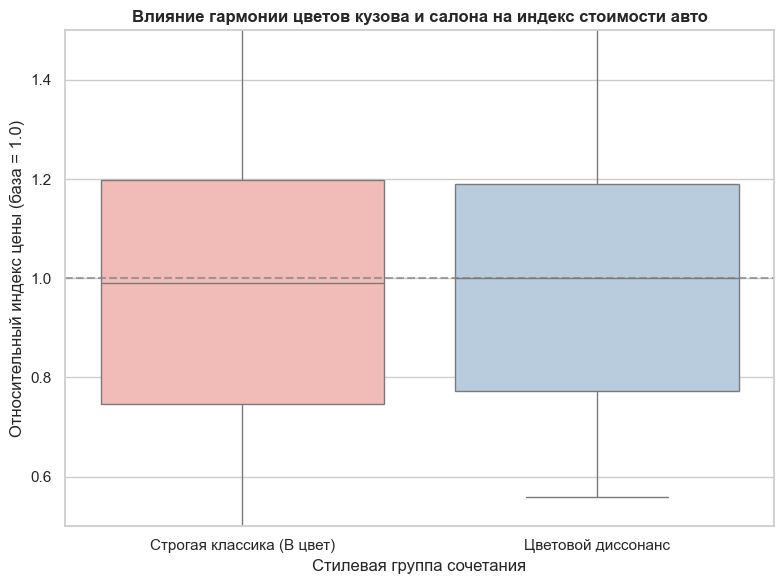

In [53]:
plt.figure(figsize=(8, 6))

# Фильтруем датафрейм только для двух нужных нам групп для наглядности
df_style_plots = df_power[df_power['style_group'].isin(['Строгая классика (В цвет)', 'Цветовой диссонанс'])].dropna(subset=['price_index'])

# Строим boxplot
sns.boxplot(x='style_group', y='price_index', hue='style_group', data=df_style_plots, 
            palette='Pastel1', order=['Строгая классика (В цвет)', 'Цветовой диссонанс'], legend=False)

plt.title('Влияние гармонии цветов кузова и салона на индекс стоимости авто', fontsize=12, fontweight='bold')
plt.xlabel('Стилевая группа сочетания')
plt.ylabel('Относительный индекс цены (база = 1.0)')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7)

# Ограничиваем ось Y для лучшей читаемости структуры ящиков
plt.ylim(0.5, 1.5)

plt.tight_layout()
plt.show()